In [10]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [11]:
pressure_array = np.arange(1000, 5475)
print(pressure_array)
print(len(pressure_array))

[1000 1001 1002 ... 5472 5473 5474]
4475


In [ ]:
# in terms of Pressure

# def temp_strat(pressure: float) -> float:
#     """International Standard Atmosphere stratospheric temperature."""
#     if pressure > 5474.9:
#         return 216.6
#     elif pressure > 868.02:
#         return 216.6 + 12.0 * np.log(pressure / 5474.9) / np.log(868.02 / 5474.9)
#     elif pressure > 110.91:
#         return 228.6 + 42.0 * np.log(pressure / 868.02) / np.log(110.91 / 868.02)
#     elif pressure > 66.939:
#         return 270.6
#     else:
#         return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)

In [ ]:
# also in terms of Pressure

# temp_strats = np.zeros(4475)

# for i in range(1, 4475):
#     pressure_value = pressure_array[i]
#     temp_value = temp_strat(pressure_value)
#     temp_strats[i] = temp_value



In [55]:
altitude_array = np.arange(20000, 72000)
print(altitude_array)
print(len(altitude_array))

[20000 20001 20002 ... 71997 71998 71999]
52000


In [56]:
temp_strats = np.zeros(52000)

for i in range(1, 52000):
    altitude_value = altitude_array[i]
    temp_value = temp_strat(altitude_value)
    temp_strats[i] = temp_value

In [57]:
# in terms of geometric altitude 

def temp_strat(altitude: float) -> float:
    """International Standard Atmosphere stratospheric temperature."""
    if altitude < 20063:
        return 216.6
    elif altitude < 32162:
        return 216.6 + 12.0 * np.log(altitude / 20063) / np.log(32162 / 20063)
    elif altitude < 47350:
        return 228.6 + 42.0 * np.log(altitude / 32162) / np.log(47350 / 32162)
    elif altitude < 51412:
        return 270.6
    else:
        return 270.6 - 56.0 * np.log(altitude / 51412) / np.log(71802 / 51412)

In [58]:
print(temp_strats)

[  0.         216.6        216.6        ... 214.14532862 214.14300014
 214.1406717 ]


Text(0, 0.5, 'Altitude / km')

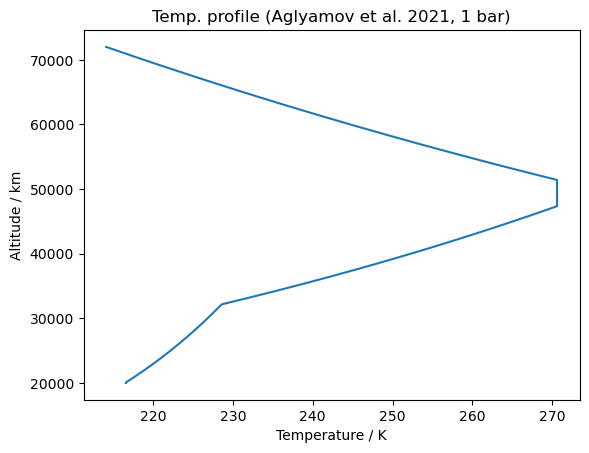

In [59]:
plt.plot(temp_strats[1:], altitude_array[1:])
plt.title('Temp. profile (Aglyamov et al. 2021, 1 bar)')
plt.xlabel('Temperature / K')
plt.ylabel('Altitude / km')

In [74]:
altitudes_lowlim = np.where(altitude_array >= 20063)
altitudes_uplim = np.where(altitude_array <= 47350)
# altitudes_lowlim
# altitudes_uplim
stratosphere_alts = altitude_array[64:27349]
stratosphere_alts

array([20064, 20065, 20066, ..., 47346, 47347, 47348], shape=(27285,))

Text(0, 0.5, 'Altitude / km')

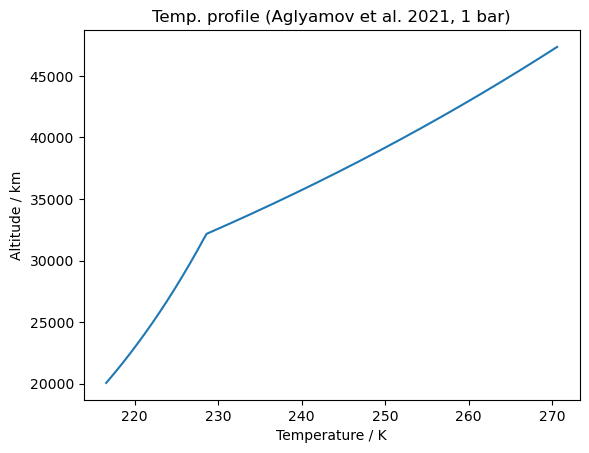

In [75]:
plt.plot(temp_strats[64:27349], altitude_array[64:27349])
plt.title('Temp. profile (Aglyamov et al. 2021, 1 bar)')
plt.xlabel('Temperature / K')
plt.ylabel('Altitude / km')

In [77]:
np.savetxt('/data/cluster4/jj22956/thunderstruck_files/stratosphere_temperature_array', temp_strats[64:27349])
# np.savetxt('/data/cluster4/jj22956/thunderstruck_files/stratosphere_pressure_array', pressure_array[1:])
np.savetxt('/data/cluster4/jj22956/thunderstruck_files/stratosphere_altitude_array', altitude_array[64:27349])